# Pandas 시각화
판다스 자체적으로 matplotlib 를 기반으로 한 시각화기능을 지원한다.    
Series나 DataFrame에 'plot() 함수'나 'plot accessor'를 사용한다.    
matplotlib을 이용해 그래프에 대한 설정을 추가로 할 수 있다.
- https://pandas.pydata.org/pandas-docs/stable/user_guide/visualization.html

## plot() 
- kind 매개변수에 지정한 값에 따라 다양한 그래프를 그릴 수 있다.
- **kind** : 그래프 종류 지정
    - **'line'**: line plot (default)
    - **'bar'**: vertical bar plot
    - **'barh'**: horizontal bar plot
    - **'hist'**: histogram
    - **'box'**: boxplot
    - **'kde'**: Kernel Density Estimation plot
    - **'pie'**: pie plot
    - **'scatter'**: scatter plot

- X 축은 index를 y축은 Series의 값를 놓고 각 그래프를 그린다.
- DataFrame을 이용해 그래프를 그릴 경우 하나의 subplot에 컬럼별로 각각 그린다.

## 막대 그래프
- index가 무슨 값인지를 가리키는 축으로 사용된다. ==> 라벨로 사용

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

tips = pd.read_csv('data/tips.csv')
tips.shape

(244, 7)

In [2]:
tips['sex'].value_counts()

sex
Male      157
Female     87
Name: count, dtype: int64

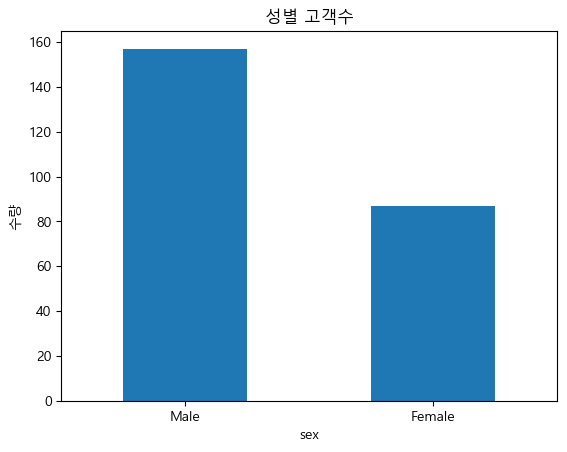

In [3]:
# 성별 고객수
v = tips['sex'].value_counts()
v.plot(kind='bar', rot=0)  # kind로 그래프 종류 설정 / 라벨이 90도 꺾여서 나와서 0도로 평평하게 나오게 함. 45도도 많이 사용

# 'pandas'는 내부적으로 'matplotlib 사용'해서 그래프를 그린다.
# 그래서 추가 설정은 plot()의 파라미터로 전달  또는 matplotlib의 함수 사용할 수있다.
plt.title("성별 고객수")
plt.ylabel("수량")
plt.show()

In [ ]:
# v.accessor.메소드()
# accessor - plot.~() / str.~() / dt.~()

v.plot.bar()
plt.show()

In [11]:
# help() 외에 주피터 노트북에서는 앞 또는 뒤에 ?를 붙이면 info 확인 가능
v.plot?

Signature:      v.plot(*args, **kwargs)
Type:           PlotAccessor
String form:    <pandas.plotting.PlotAccessor object at 0x0000021D00175EB0>
File:           c:\documents\skn31\05_시각화\.venv\lib\site-packages\pandas\plotting\__init__.py
Docstring:     
Make plots of Series or DataFrame.

Uses the backend specified by the
option ``plotting.backend``. By default, matplotlib is used.

Parameters
----------
data : Series or DataFrame
    The object for which the method is called.

Attributes
----------
x : label or position, default None
    Only used if data is a DataFrame.
y : label, position or list of label, positions, default None
    Allows plotting of one column versus another. Only used if data is a
    DataFrame.
kind : str
    The kind of plot to produce:

    - 'line' : line plot (default)
    - 'bar' : vertical bar plot
    - 'barh' : horizontal bar plot
    - 'hist' : histogram
    - 'box' : boxplot
    - 'kde' : Kernel Density Estimation plot
    - 'density' : same as 'kde'

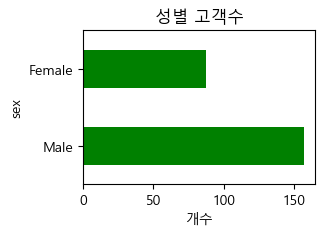

In [4]:
v.plot(kind='barh', title="성별 고객수", xlabel='개수', figsize=(3, 2), color="green")
plt.show()  # 생략 시 axis 출력되는 것 안 보이게 함(or 위 코드 맨 뒤에 ; 붙여도 안 보임)

In [5]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [6]:
# df일 때는 열 기준으로 그래프 그림
# 성별-흡연여부별 손님 수
result = tips.pivot_table(index="sex", columns="smoker", values="total_bill", aggfunc="count")
result

smoker,No,Yes
sex,,
Female,54,33
Male,97,60


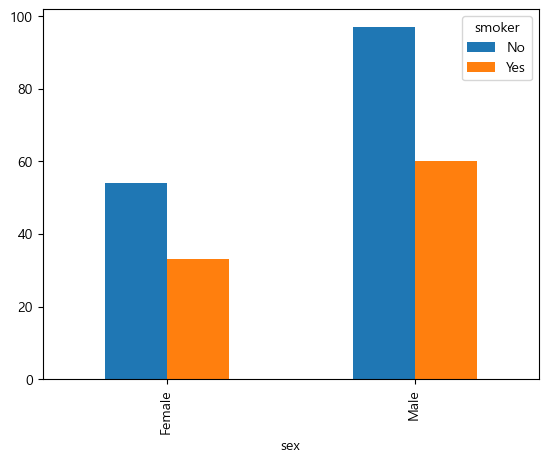

In [7]:
result.plot(kind='bar') # df로 그림
plt.show()

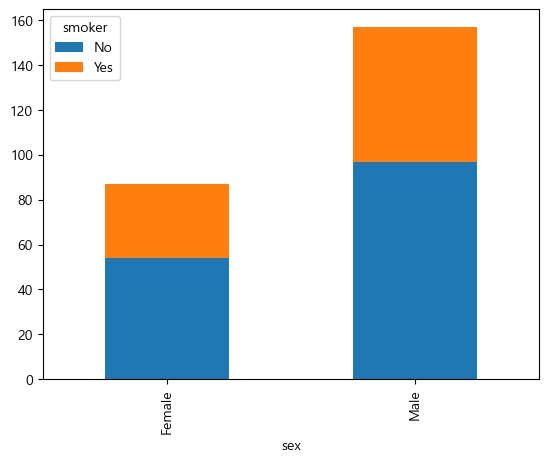

In [8]:
result.plot(
    kind='bar', 
    stacked=True #  막대: 전체 개수, smoker 별 비율로 나눠줌.
)
plt.show()

In [9]:
result = tips.pivot_table(index="smoker", columns='day', values='total_bill', aggfunc="sum")
result

day,Fri,Sat,Sun,Thur
smoker,,,,
No,73.68,884.78,1168.88,770.09
Yes,252.20,893.62,458.28,326.24


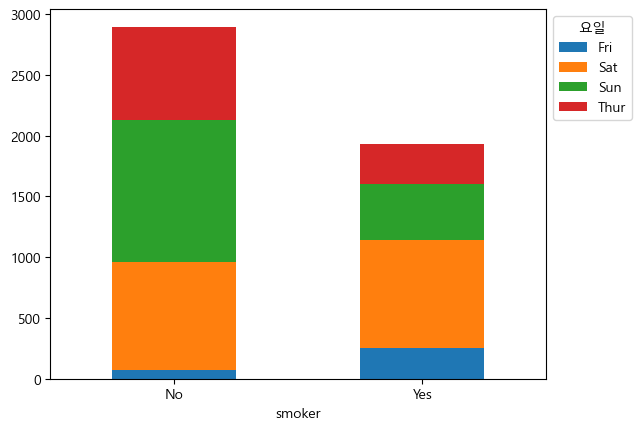

In [11]:
# result.plot(kind='bar')
result.plot(kind='bar', stacked=True, rot=0)
plt.legend(bbox_to_anchor=(1,1), loc="upper left", title="요일")
plt.show()

## 파이차트

In [12]:
tips['day'].value_counts()

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

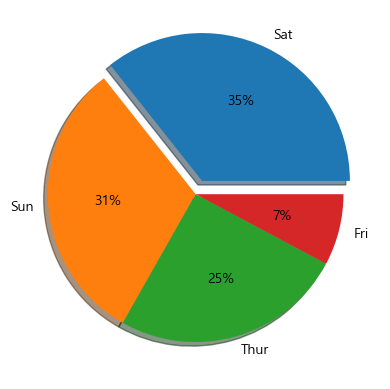

In [13]:
tips['day'].value_counts().plot(
    kind='pie', autopct="%d%%",
    explode=[0.1, 0, 0, 0], shadow=True
)
plt.show()
# 항상 인덱스 이름은 라벨로 나옴

## 히스토그램, KDE(밀도그래프)
 - 어디에 값이 많고 적은지 확인
 - KDE : 히스토그램 모양을 이은 부드러운 곡선 그래프

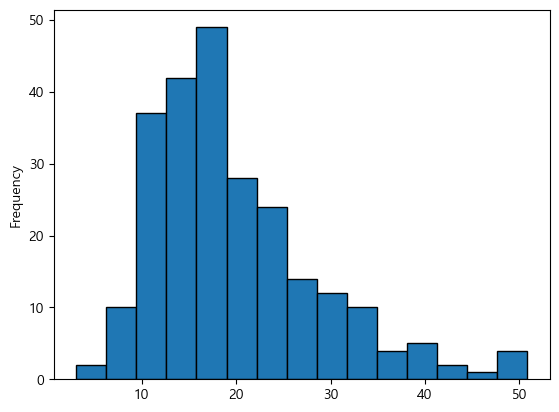

In [14]:
tips['total_bill'].plot(
    kind="hist", 
    bins=15,  # List
    edgecolor="k"
)
plt.show()

In [15]:
# !uv pip install scipy

Resolved 2 packages in 356ms
 Downloaded scipy
Prepared 1 package in 2.30s
Installed 1 package in 468ms
 + scipy==1.17.1


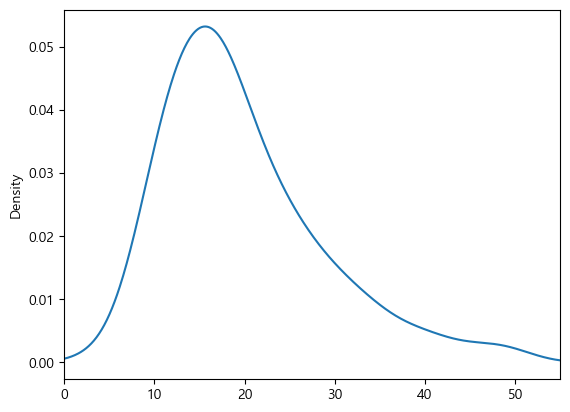

In [17]:
tips['total_bill'].plot(kind="kde") 
plt.xlim(0, 55)
plt.show()

In [18]:
tips[['tip', 'total_bill']]

,tip,total_bill
0,1.01,16.99
1,1.66,10.34
2,3.50,21.01
3,3.31,23.68
4,3.61,24.59
...,...,...
239,5.92,29.03
240,2.00,27.18
241,2.00,22.67
242,1.75,17.82


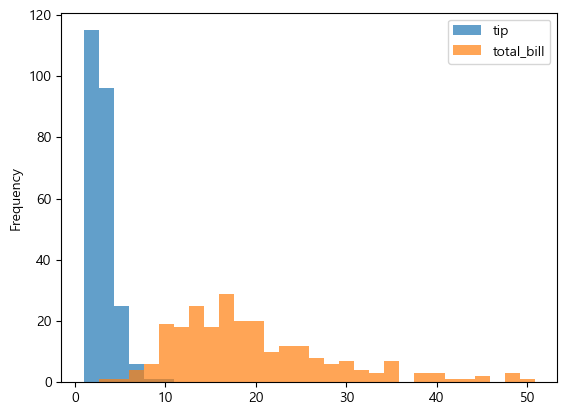

In [19]:
# DataFrame
tips[['tip', 'total_bill']].plot(kind='hist', alpha=0.7, bins=30)
plt.show()

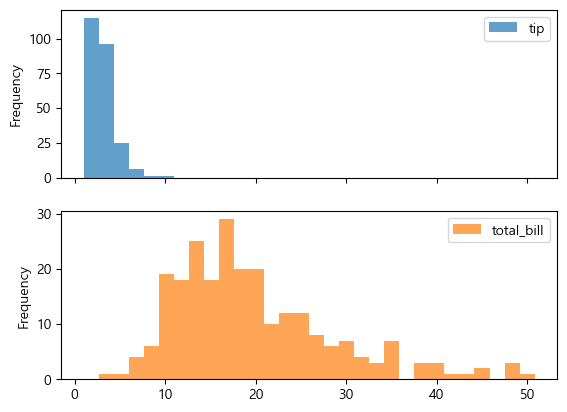

In [20]:
# DataFrame
tips[['tip', 'total_bill']].plot(
    kind='hist', alpha=0.7, bins=30, 
    subplots=True
    , layout=(1, 2) # subplot들의 layout 설정(행 수 , 열 수)
) # 여러 개 axes에 나눠서 그림 
plt.show()

## Boxplot (상자그래프)

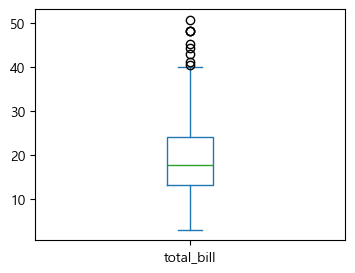

In [21]:
tips['total_bill'].plot(kind="box", figsize=(4, 3))
plt.show()

In [24]:
q1, q2, q3 = tips['total_bill'].quantile(q=[0.25, 0.5, 0.75])
print(q1, q2, q3)

whis = 1.5 #  범위를 조정하는 파라미터
iqr = q3 - q1
nr1 = q1 - iqr * whis
nr2 = q3 + iqr * whis
nr1, nr2

# -2.8 ~ 40.3 : 정상 범위. -2.8 아래, 40.3 위는 이상치

13.3475 17.795 24.127499999999998


(-2.8224999999999945, 40.29749999999999)

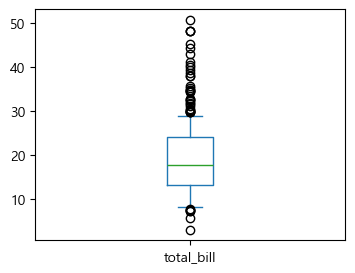

In [25]:
# 이상치 조정
tips['total_bill'].plot(kind="box", whis=0.5, figsize=(4, 3)) 
plt.show()

In [27]:
tips[['tip', 'total_bill']]

,tip,total_bill
0,1.01,16.99
1,1.66,10.34
2,3.50,21.01
3,3.31,23.68
4,3.61,24.59
...,...,...
239,5.92,29.03
240,2.00,27.18
241,2.00,22.67
242,1.75,17.82


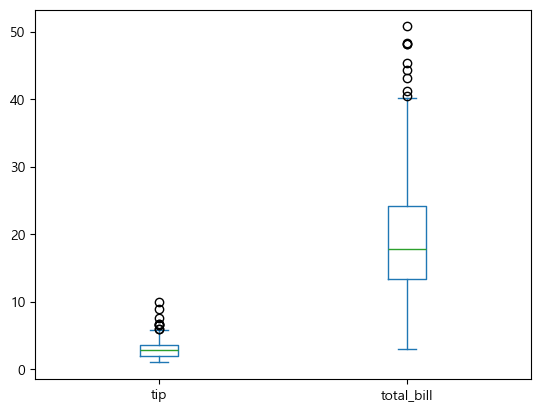

In [26]:
tips[['tip', 'total_bill']].plot(kind="box")
plt.show()

## scatter plot (산점도) 

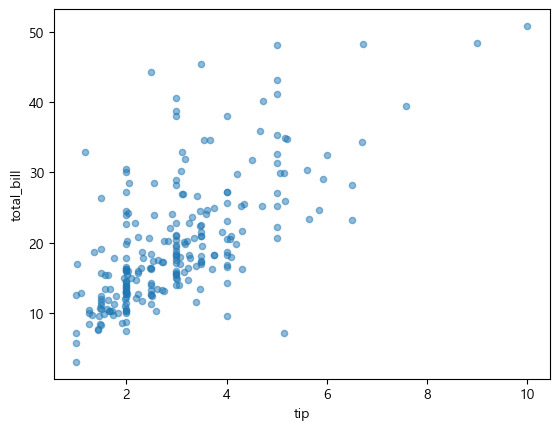

In [28]:
# df.plot(kind='scatter', x="x축에 놓을 컬럼 이름", y="y축에 놓을 컬럼 이름")
tips.plot(kind="scatter", x="tip", y="total_bill", alpha=0.5)
plt.show()

In [29]:
tips[['tip', 'total_bill']].corr()

,tip,total_bill
tip,1.000000,0.675734
total_bill,0.675734,1.000000


In [30]:
dia = pd.read_csv("data/diamonds.csv")
v = dia.select_dtypes(include="number").corr()
v

# 히트맵(상관계수 컬러로 시각화 시 사용.)

,carat,depth,table,price,x,y,z
carat,1.000000,0.028224,0.181618,0.921591,0.975094,0.951722,0.953387
depth,0.028224,1.000000,-0.295779,-0.010647,-0.025289,-0.029341,0.094924
table,0.181618,-0.295779,1.000000,0.127134,0.195344,0.183760,0.150929
price,0.921591,-0.010647,0.127134,1.000000,0.884435,0.865421,0.861249
x,0.975094,-0.025289,0.195344,0.884435,1.000000,0.974701,0.970772
y,0.951722,-0.029341,0.183760,0.865421,0.974701,1.000000,0.952006
z,0.953387,0.094924,0.150929,0.861249,0.970772,0.952006,1.000000


### 컬럼 간 상관계수 시각화
- matplotlib의 'imshow()'를 이용해 그린다.

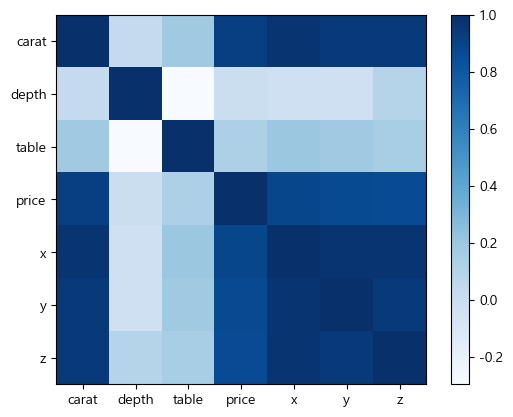

In [37]:
plt.imshow(v, cmap="Blues")
plt.colorbar()
plt.xticks(range(0, 7), labels=v.columns)
plt.yticks(range(0, 7), labels=v.columns)
plt.show()

# cmap(color map) - 여러 색 사용 시 컬러 순서 정한 것, ="~s" - 한 가지 색으로 농도 조절

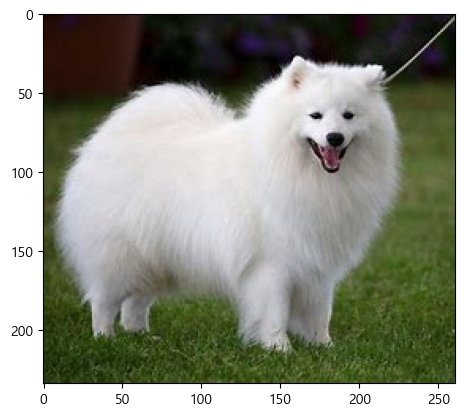

In [ ]:
from PIL import Image
import numpy as np

#사진을 불러오기
img = np.array(Image.open("image.jpg"))

#matplotlib imshow를 이용해 출력(알아서 resizing)
plt.imshow(img)
plt.show()

In [39]:
print(img)
# 픽셀 하나에 대한 rgb 값들 출력

[[[ 32   4   3]
  [ 32   4   1]
  [ 30   5   1]
  ...
  [ 45  41  42]
  [ 11   7   8]
  [ 34  30  31]]

 [[ 33   5   4]
  [ 33   5   2]
  [ 31   6   1]
  ...
  [ 21  17  16]
  [ 40  36  35]
  [ 54  50  49]]

 [[ 31   6   2]
  [ 31   6   2]
  [ 31   6   1]
  ...
  [ 18  14  11]
  [101  97  94]
  [101  97  94]]

 ...

 [[ 39  55  18]
  [ 36  52  15]
  [ 41  57  20]
  ...
  [ 55  73  25]
  [ 63  81  33]
  [ 66  84  36]]

 [[ 47  63  26]
  [ 45  61  24]
  [ 41  57  20]
  ...
  [ 52  70  22]
  [ 64  82  34]
  [ 61  79  31]]

 [[ 48  64  27]
  [ 46  62  25]
  [ 42  58  21]
  ...
  [ 49  67  19]
  [ 64  82  34]
  [ 64  82  34]]]


# line plot

In [40]:
df = pd.read_excel("data/강수량.xlsx", index_col="계절").T
df

계절,봄,여름,가을,겨울
2009,231.3,752.0,143.1,142.3
2010,302.9,692.6,307.6,98.7
2011,256.9,1053.6,225.5,45.6
2012,256.5,770.6,363.5,139.3
2013,264.3,567.5,231.2,59.9
2014,215.9,599.8,293.1,76.9
2015,223.2,387.1,247.7,109.1
2016,312.8,446.2,381.6,108.1
2017,118.6,609.7,172.5,75.6


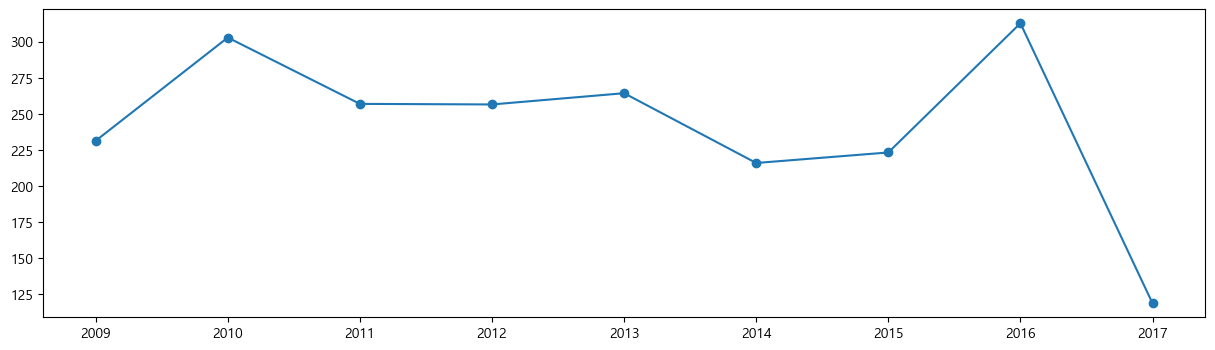

In [41]:
df['봄'].plot(figsize=(15, 4), marker="o") # default plot: line -> kind='line' 생략
plt.show()

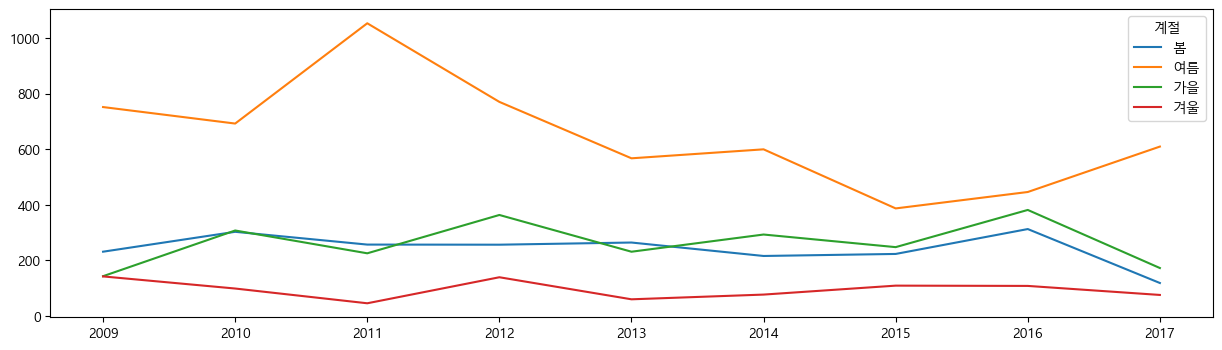

In [44]:
df.plot(figsize=(15,4)) # 기본적으로 컬럼에 대해 그림
# df.plot(figsize=(15,4), subplots=True)
plt.show()

In [45]:
df.T

,2009,2010,2011,2012,2013,2014,2015,2016,2017
계절,,,,,,,,,
봄,231.3,302.9,256.9,256.5,264.3,215.9,223.2,312.8,118.6
여름,752.0,692.6,1053.6,770.6,567.5,599.8,387.1,446.2,609.7
가을,143.1,307.6,225.5,363.5,231.2,293.1,247.7,381.6,172.5
겨울,142.3,98.7,45.6,139.3,59.9,76.9,109.1,108.1,75.6


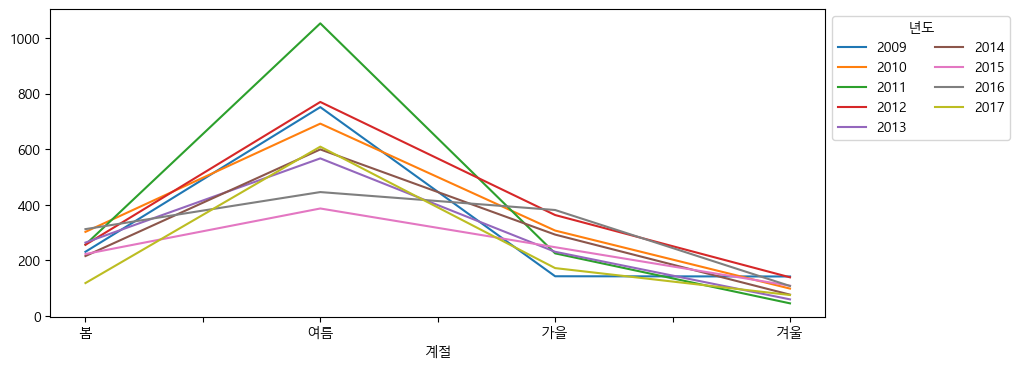

In [49]:
# 계절에 대한 연도별 강수량
df.T.plot(figsize=(10,4))
plt.legend(bbox_to_anchor=(1,1), loc="upper left", title="년도", ncols=2)
plt.show()